# Versão 3 - Pré-processamento

Nesta etapa, transformamos arquivos brutos do dataset em uma representação pronta para modelagem. Isso inclui:

1. dividir a base em treino, validação e teste
2. escolher variáveis auxiliares úteis
3. ajustar normalizações usando apenas o treino
4. criar features derivadas para capturar dinâmica temporal
5. salvar o resultado em arquivos `.parquet` já preparados para o treinamento

Em séries temporais, essa etapa é crítica porque pequenas decisões de preparação podem afetar diretamente a qualidade do modelo.

## 1.Preparação do ambiente

Aqui carregamos as funções do `pipeline_v3.py` que fazem limpeza, seleção de colunas, ajuste de escalas e transformação das séries em um formato padronizado.

In [1]:
from __future__ import annotations

#resolve os caminhos para importar o pipeline mesmo quando o notebook e executado de lugares diferentes
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()
CANDIDATE_DIRS = [
    CURRENT_DIR,
    CURRENT_DIR / "versao3",
    CURRENT_DIR.parent / "versao3",
]
NOTEBOOK_DIR = next((candidate for candidate in CANDIDATE_DIRS if (candidate / "pipeline_v3.py").exists()), CURRENT_DIR)
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

#carrega bibliotecas de apoio para tabelas e visualizacao
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

#importa apenas as funcoes usadas neste notebook para deixar o fluxo mais claro para estudo
from pipeline_v3 import (
    collect_training_reference_frame,
    discover_all_dataset_files,
    fit_preprocessing_bundle,
    save_bundle,
    select_auxiliary_columns,
    set_seed,
    split_manifest_by_series,
    transform_frame_to_engineered_features,
    update_bundle_split_files,
)

#fixa a semente para tornar o pipeline reprodutivel
set_seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

## 2.Definição de caminhos e limpeza da saída anterior

O diretório `artifacts/preprocessed_v3` guarda os arquivos já tratados. Antes de gerar uma nova versão, removemos os `.parquet` antigos para não misturar saídas de execuções diferentes.

In [2]:
#define os caminhos principais usados durante o pre processamento
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name in {"versao1", "versao2", "versao3"} else CURRENT_DIR
DATASET_ROOT = PROJECT_ROOT / "3W" / "dataset"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
PREPROCESSED_V3_DIR = ARTIFACTS_DIR / "preprocessed_v3"
BUNDLE_PATH = PREPROCESSED_V3_DIR / "preprocessing_bundle_v3.json"
MANIFEST_PATH = PREPROCESSED_V3_DIR / "dataset_manifest_v3.csv"
SPLIT_MANIFEST_PATH = PREPROCESSED_V3_DIR / "dataset_manifest_split_v3.csv"

#define parametros da engenharia de atributos temporais
ROLLING_WINDOW = 5
SEQUENCE_LENGTH = 60

#garante a existencia das pastas de saida
PREPROCESSED_V3_DIR.mkdir(parents=True, exist_ok=True)
for split_name in ["train", "validation", "test"]:
    split_dir = PREPROCESSED_V3_DIR / split_name
    split_dir.mkdir(parents=True, exist_ok=True)

    #remove arquivos antigos para evitar mistura entre versoes de preprocessamento
    for old_file in split_dir.glob("*.parquet"):
        old_file.unlink()

## 3.Criação do manifesto e divisão em treino, validação e teste

Cada série inteira precisa cair em apenas um dos splits. Isso evita vazamento de informação, isto é, o modelo ver uma série muito parecida no treino e depois ser avaliado em outra parte dela no teste.

In [3]:
#descobre todos os arquivos da base e salva um manifesto bruto para auditoria
manifest_df = discover_all_dataset_files(DATASET_ROOT)
manifest_df.to_csv(MANIFEST_PATH, index=False)

#divide as series por split mantendo cada arquivo inteiro em um unico conjunto
split_manifest_df = split_manifest_by_series(manifest_df, train_frac=0.7, validation_frac=0.15)
split_manifest_df.to_csv(SPLIT_MANIFEST_PATH, index=False)

#resume quantos arquivos, classes e wells aparecem em cada parte
manifest_overview_df = pd.DataFrame(
    [
        {
            "split": split_name,
            "arquivos": len(split_df),
            "classes": split_df["class_label"].nunique(),
            "wells": split_df["well_name"].nunique(),
        }
        for split_name, split_df in split_manifest_df.groupby("split", sort=False)
    ]
)

display(manifest_overview_df)
split_manifest_df.head()

,split,arquivos,classes,wells
0,train,1554,10,42
1,validation,314,10,25
2,test,360,10,27


,class_label,well_name,start_token,series_id,source_type,file_path,split
0,0,WELL-00001,20170201010207,0__WELL-00001_20170201010207,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,train
1,0,WELL-00001,20170201060114,0__WELL-00001_20170201060114,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,train
2,0,WELL-00001,20170201110124,0__WELL-00001_20170201110124,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,train
3,0,WELL-00001,20170201160311,0__WELL-00001_20170201160311,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,train
4,0,WELL-00001,20170201210228,0__WELL-00001_20170201210228,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,train


### Como interpretar a divisão

O resultado mostra **1554 séries de treino**, **314 de validação** e **360 de teste**. As **10 classes aparecem em todos os splits**, o que é importante para que o modelo aprenda e seja avaliado em todos os tipos de comportamento.

Repare também que o conjunto de teste já é grande em número de séries. Mais adiante, quando cada série for convertida em várias janelas temporais, esse volume crescerá bastante.

## 4.Seleção de variáveis auxiliares

Além das variáveis-alvo que queremos prever, o pipeline pode usar sinais auxiliares. Nesta etapa, escolhemos colunas que realmente variam e portanto têm potencial para ajudar o modelo.

In [4]:
#filtra apenas o manifesto de treino porque a escolha de atributos deve ser baseada no conjunto de treino
train_manifest_df = split_manifest_df.loc[split_manifest_df["split"] == "train"].reset_index(drop=True)

#monta um grande dataframe de referencia para medir variabilidade das colunas auxiliares
training_reference_df = collect_training_reference_frame(train_manifest_df)
auxiliary_summary_df = select_auxiliary_columns(training_reference_df)

#mantem apenas as colunas auxiliares consideradas informativas
selected_auxiliary_columns = auxiliary_summary_df.loc[auxiliary_summary_df["selected_for_input"], "column"].tolist()

display(auxiliary_summary_df)
selected_auxiliary_columns

,column,null_pct,nunique,std,selected_for_input
0,ESTADO-DHSV,0.0,2,3.141481e-01,True
1,ESTADO-M1,0.0,2,4.029200e-01,True
2,ESTADO-M2,0.0,3,2.636932e-01,True
3,ESTADO-PXO,0.0,2,5.276293e-02,True
4,ESTADO-SDV-GL,0.0,2,3.297999e-01,True
5,ESTADO-SDV-P,0.0,2,4.588971e-01,True
6,ESTADO-W1,0.0,2,3.823339e-01,True
7,ESTADO-W2,0.0,3,2.344673e-01,True
8,ESTADO-XO,0.0,2,3.227150e-02,True
9,P-PDG,0.0,19149304,8.816796e+40,True


['ESTADO-DHSV',
 'ESTADO-M1',
 'ESTADO-M2',
 'ESTADO-PXO',
 'ESTADO-SDV-GL',
 'ESTADO-SDV-P',
 'ESTADO-W1',
 'ESTADO-W2',
 'ESTADO-XO',
 'P-PDG',
 'QGL',
 'T-PDG']

Todas as 12 colunas auxiliares candidatas foram selecionadas. Isso significa que, dentro do critério usado aqui, todas apresentam variação suficiente para entrar como entrada do modelo.

Para um aluno iniciante, vale a regra prática: uma variável quase constante costuma ajudar pouco, porque ela oferece pouca informação nova ao modelo.

## 5.Ajuste do bundle de pré-processamento

O `bundle` é um pacote com tudo o que será necessário nas próximas etapas: colunas escolhidas, médias e desvios da normalização, limites de clipping e mapeamento dos poços para identificadores numéricos.

In [5]:
#ajusta normalizadores e estatisticas usando apenas o conjunto de treino
bundle = fit_preprocessing_bundle(
    train_manifest=train_manifest_df,
    auxiliary_columns=selected_auxiliary_columns,
    max_files_per_well=None,
    rolling_window=ROLLING_WINDOW,
    sequence_length_recommendation=SEQUENCE_LENGTH,
)

#registra no bundle quais arquivos pertencem a cada split
bundle = update_bundle_split_files(bundle, split_manifest_df)
save_bundle(bundle, BUNDLE_PATH)

#resume a quantidade de features de entrada e saida
pd.DataFrame(
    {
        "aspecto": ["input_features", "target_features", "auxiliary_features", "well_ids"],
        "valor": [len(bundle.input_columns), len(bundle.target_columns), len(bundle.auxiliary_columns), len(bundle.well_to_id)],
    }
)

/home/tiagoriosrocha/Desktop/lstm-w3/.venv/lib/python3.12/site-packages/pandas/core/internals/managers.py:1772: RuntimeWarning: overflow encountered in cast
  result[rl.indexer] = arr
/home/tiagoriosrocha/Desktop/lstm-w3/.venv/lib/python3.12/site-packages/pandas/core/internals/managers.py:1772: RuntimeWarning: overflow encountered in cast
  result[rl.indexer] = arr
/home/tiagoriosrocha/Desktop/lstm-w3/.venv/lib/python3.12/site-packages/pandas/core/internals/managers.py:1772: RuntimeWarning: overflow encountered in cast
  result[rl.indexer] = arr


,aspecto,valor
0,input_features,36
1,target_features,6
2,auxiliary_features,12
3,well_ids,42


O bundle final ficou com **36 features de entrada**, **6 variáveis-alvo** e **42 identificadores de poços**.

Os avisos de `overflow encountered in cast` vistos na execução sugerem que algumas colunas brutas têm escala numérica muito alta. Isso não significa automaticamente erro fatal, porque o pipeline aplica clipping e normalização, mas é um sinal útil para investigação futura.

## 6.Transformação das séries para o formato de modelagem

Agora cada arquivo bruto é lido, limpo, normalizado e enriquecido com novas features temporais. O resultado é salvo em `.parquet`, separado por split.

In [6]:
#processa cada serie individualmente e salva uma versao pronta para modelagem
transformation_rows = []
for row in split_manifest_df.itertuples(index=False):
    #transforma a serie bruta em uma tabela com targets normalizados e features derivadas
    engineered_df = transform_frame_to_engineered_features(row.file_path, bundle)

    #salva a saida em parquet para reutilizar nas etapas seguintes sem repetir o preprocessamento
    output_name = f"{row.split}__{row.class_label}__{Path(row.file_path).stem}.parquet"
    output_path = PREPROCESSED_V3_DIR / row.split / output_name
    engineered_df.to_parquet(output_path, index=False)

    #guarda um resumo para auditoria
    transformation_rows.append(
        {
            "split": row.split,
            "class_label": row.class_label,
            "series_id": row.series_id,
            "rows": len(engineered_df),
            "input_features": len(bundle.input_columns),
            "target_features": len(bundle.target_columns),
            "output_file": str(output_path),
        }
    )

transformation_summary_df = pd.DataFrame(transformation_rows)
transformation_summary_df.head()

/home/tiagoriosrocha/Desktop/lstm-w3/.venv/lib/python3.12/site-packages/pandas/core/internals/managers.py:1772: RuntimeWarning: overflow encountered in cast
  result[rl.indexer] = arr
/home/tiagoriosrocha/Desktop/lstm-w3/.venv/lib/python3.12/site-packages/pandas/core/internals/managers.py:1772: RuntimeWarning: overflow encountered in cast
  result[rl.indexer] = arr
/home/tiagoriosrocha/Desktop/lstm-w3/.venv/lib/python3.12/site-packages/pandas/core/internals/managers.py:1772: RuntimeWarning: overflow encountered in cast
  result[rl.indexer] = arr


,split,class_label,series_id,rows,input_features,target_features,output_file
0,train,0,0__WELL-00001_20170201010207,21474,36,6,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...
1,train,0,0__WELL-00001_20170201060114,21527,36,6,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...
2,train,0,0__WELL-00001_20170201110124,21517,36,6,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...
3,train,0,0__WELL-00001_20170201160311,21410,36,6,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...
4,train,0,0__WELL-00001_20170201210228,21453,36,6,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...


Esse resumo confirma que cada série gerou um arquivo processado com o mesmo número de targets e de features de entrada. Essa padronização é essencial para alimentar lotes homogêneos no treinamento.

## 7.Inspeção do resultado processado

Aqui verificamos quanto dado foi gerado por split e observamos um arquivo já transformado para entender o significado das novas colunas.

In [7]:
#resume a quantidade de arquivos e linhas processadas por split e por classe
processed_overview_df = (
    transformation_summary_df.groupby(["split", "class_label"], as_index=False)
    .agg(
        arquivos=("series_id", "count"),
        linhas_totais=("rows", "sum"),
        linhas_medias=("rows", "mean"),
    )
    .sort_values(["split", "class_label"])
)

#abre um exemplo real da versao processada para mostrar as colunas geradas
sample_file = sorted((PREPROCESSED_V3_DIR / "train").glob("*.parquet"))[0]
sample_engineered_df = pd.read_parquet(sample_file)

display(processed_overview_df)
sample_engineered_df.head()

,split,class_label,arquivos,linhas_totais,linhas_medias
0,test,0,96,1912818,19925.187500
1,test,1,20,1619983,80999.150000
2,test,2,7,122229,17461.285714
3,test,3,18,875977,48665.388889
4,test,4,57,612045,10737.631579
5,test,5,69,2041046,29580.376812
6,test,6,35,912607,26074.485714
7,test,7,9,1570350,174483.333333
8,test,8,15,1127792,75186.133333
9,test,9,34,1610140,47357.058824


,series_id,well_name,class_label,source_type,well_id,file_path,timestamp,target__P-ANULAR,target__P-JUS-CKGL,target__P-MON-CKP,target__P-TPT,target__T-JUS-CKP,target__T-TPT,raw__P-ANULAR,raw__P-JUS-CKGL,raw__P-MON-CKP,raw__P-TPT,raw__T-JUS-CKP,raw__T-TPT,raw__ESTADO-DHSV,raw__ESTADO-M1,raw__ESTADO-M2,raw__ESTADO-PXO,raw__ESTADO-SDV-GL,raw__ESTADO-SDV-P,raw__ESTADO-W1,raw__ESTADO-W2,raw__ESTADO-XO,raw__P-PDG,raw__QGL,raw__T-PDG,diff1__P-ANULAR,diff1__P-JUS-CKGL,diff1__P-MON-CKP,diff1__P-TPT,diff1__T-JUS-CKP,diff1__T-TPT,dev_roll5__P-ANULAR,dev_roll5__P-JUS-CKGL,dev_roll5__P-MON-CKP,dev_roll5__P-TPT,dev_roll5__T-JUS-CKP,dev_roll5__T-TPT,std_roll5__P-ANULAR,std_roll5__P-JUS-CKGL,std_roll5__P-MON-CKP,std_roll5__P-TPT,std_roll5__T-JUS-CKP,std_roll5__T-TPT
0,0__WELL-00001_20170201010207,WELL-00001,0,well,2,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,2017-02-01 01:02:07,0.921026,-0.476867,-0.451439,-0.336274,0.967825,0.857208,0.921026,-0.476867,-0.451439,-0.336274,0.967825,0.857208,2.829834,1.975744,-0.285191,-0.052911,-0.376566,1.522189,2.150509,-0.249009,-0.032305,-1.182512,-0.406216,0.075133,0.00026,-0.004964,-0.000987,-0.004588,0.007381,0.011794,0.000315,-0.005866,-0.001127,-0.005603,0.009016,0.017227,-0.114727,-0.033881,-0.234973,-0.234765,-0.139992,-0.171121
1,0__WELL-00001_20170201010207,WELL-00001,0,well,2,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,2017-02-01 01:02:08,0.921026,-0.476867,-0.449708,-0.336274,0.967626,0.857208,0.921026,-0.476867,-0.449708,-0.336274,0.967626,0.857208,2.829834,1.975744,-0.285191,-0.052911,-0.376566,1.522189,2.150509,-0.249009,-0.032305,-1.182512,-0.406216,0.075133,0.00026,-0.004964,0.465539,-0.004588,-0.148559,0.011794,0.000315,-0.005866,0.132009,-0.005603,-0.038606,0.017227,-0.114727,-0.033881,0.002844,-0.234765,-0.057897,-0.171121
2,0__WELL-00001_20170201010207,WELL-00001,0,well,2,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,2017-02-01 01:02:09,0.921026,-0.476867,-0.447977,-0.336274,0.967427,0.857208,0.921026,-0.476867,-0.447977,-0.336274,0.967427,0.857208,2.829834,1.975744,-0.285191,-0.052911,-0.376566,1.522189,2.150509,-0.249009,-0.032305,-1.182512,-0.406216,0.075133,0.00026,-0.004964,0.465454,-0.004588,-0.148314,0.011794,0.000315,-0.005866,0.265113,-0.005603,-0.086129,0.017227,-0.114727,-0.033881,0.101321,-0.234765,-0.023984,-0.171121
3,0__WELL-00001_20170201010207,WELL-00001,0,well,2,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,2017-02-01 01:02:10,0.921026,-0.476867,-0.446246,-0.336274,0.967228,0.857208,0.921026,-0.476867,-0.446246,-0.336274,0.967228,0.857208,2.829834,1.975744,-0.285191,-0.052911,-0.376566,1.522189,2.150509,-0.249009,-0.032305,-1.182512,-0.406216,0.075133,0.00026,-0.004964,0.465539,-0.004588,-0.148805,0.011794,0.000315,-0.005866,0.398258,-0.005603,-0.133890,0.017227,-0.114727,-0.033881,0.199188,-0.234765,0.009868,-0.171121
4,0__WELL-00001_20170201010207,WELL-00001,0,well,2,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,2017-02-01 01:02:11,0.921026,-0.476867,-0.444515,-0.336274,0.967029,0.857208,0.921026,-0.476867,-0.444515,-0.336274,0.967029,0.857208,2.829834,1.975744,-0.285191,-0.052911,-0.376566,1.522189,2.150509,-0.249009,-0.032305,-1.182512,-0.406216,0.075133,0.00026,-0.004709,0.465454,-0.004588,-0.148559,0.011794,0.000315,-0.005746,0.531360,-0.005603,-0.181505,0.017227,-0.114727,-0.033799,0.296754,-0.234765,0.043577,-0.171121


### Como ler o arquivo processado

- colunas `target__...`: versões normalizadas das variáveis que o modelo deve prever
- colunas `raw__...`: sinais de entrada em escala normalizada, incluindo targets passados e variáveis auxiliares
- colunas `diff1__...`: diferença entre o valor atual e o anterior, útil para capturar tendência local
- colunas `dev_roll5__...`: desvio em relação à média móvel, útil para detectar afastamento do comportamento recente
- colunas `std_roll5__...`: desvio padrão em janela móvel, útil para descrever volatilidade local

Essas features ajudam o modelo a enxergar não apenas o valor atual, mas também a dinâmica da série.

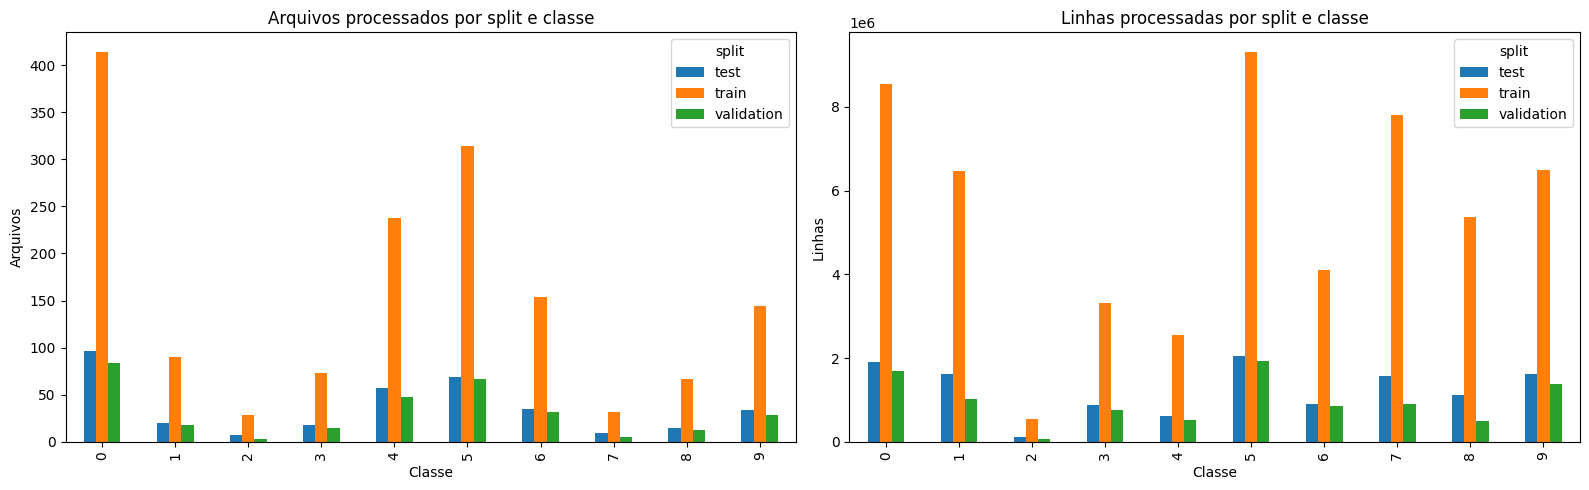

In [8]:
#compara visualmente o volume processado entre splits e classes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_rows_df = processed_overview_df.pivot(index="class_label", columns="split", values="arquivos").fillna(0)
plot_rows_df.plot(kind="bar", ax=axes[0])
axes[0].set_title("Arquivos processados por split e classe")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Arquivos")

plot_lines_df = processed_overview_df.pivot(index="class_label", columns="split", values="linhas_totais").fillna(0)
plot_lines_df.plot(kind="bar", ax=axes[1])
axes[1].set_title("Linhas processadas por split e classe")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Linhas")

plt.tight_layout()
plt.show()

## Conclusão da etapa

O pré-processamento prepara a base para o modelo aprender com segurança:

- a divisão entre treino, validação e teste foi fixada e salva em arquivo
- as features foram normalizadas usando apenas treino
- novas colunas temporais foram criadas
- o resultado foi salvo em arquivos prontos para leitura rápida nas próximas etapas

No notebook seguinte, essas tabelas processadas serão convertidas em janelas temporais para treinar o modelo recorrente.